<a href="https://colab.research.google.com/github/limco-unipisa/lezioni-julia/blob/main/09-sparse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**  
## **Esercitazione 9: matrici sparse**

In alcune applicazioni si lavora con matrici che contengono molti elementi nulli. Matrici di questo tipo sono dette *sparse*.
La definizione rigorosa di matrice sparsa può variare a seconda del contesto; generalmente una matrice $n\times n$ si considera sparsa se ha un numero di elementi non nulli dell'ordine di $O(n)$. Per fare un esempio, secondo questa definizione le matrici diagonali sono sparse (perché il numero di elementi potenzialmente non nulli è $n$), mentre le matrici triangolari superiori non sono sparse (perché il numero di elementi potenzialmente non nulli è $n(n+1)/2$).





---
# 1. Matrici sparse in Julia

In questa lezione useremo i pacchetti `SparseArrays`, `LinearAlgebra` e `Plots`.

In una matrice sparsa, vengono allocati in memoria solo gli elementi diversi da zero e i relativi indici.

Un modo per costruire una matrice sparsa è usare la funzione `sparse` e definire i vettori di indici di riga, colonna e i corrispondenti elementi non nulli. Ad esempio:

```julia
rows = [1, 3, 5]
cols = [2, 4, 6]
vals = [π, exp(1), 42]
C = sparse(rows, cols, vals, 7, 8) # C is a 7x8 sparse matrix
display (C)

# nnz restituisce il numero di elementi non nulli
println("Number of non-zeros: ", nnz(C))

In [1]:
# caricare le librerie
using SparseArrays, LinearAlgebra, Plots


In [ ]:
rows = [1, 3, 5]
cols = [2, 4, 6]
vals = [π, exp(1), 42]
C = sparse(rows, cols, vals, 7, 8) # C is a 7x8 sparse matrix

# nnz restituisce il numero di elementi non nulli
println("Number of non-zeros: ", nnz(C))

display(C)


Number of non-zeros: 3


7×8 SparseMatrixCSC{Float64, Int64} with 3 stored entries:
  ⋅   3.14159   ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅   2.71828   ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅   42.0   ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 

Una matrice sparsa può essere convertita in una matrice piena con il comando `Array` e viceversa con il comando `sparse`:

```julia
Cfull = Array(C) #Cfull è una matrice piena
display(Cfull)

Cs = sparse(Cfull) #CS è la rappresentazione sparsa di Cfull
display(Cs)

In [ ]:
Cfull = Array(C) #Cfull è una matrice piena
display(Cfull)

Cs = sparse(Cfull)
display(Cs)

7×8 Matrix{Float64}:
 0.0  3.14159  0.0  0.0      0.0   0.0  0.0  0.0
 0.0  0.0      0.0  0.0      0.0   0.0  0.0  0.0
 0.0  0.0      0.0  2.71828  0.0   0.0  0.0  0.0
 0.0  0.0      0.0  0.0      0.0   0.0  0.0  0.0
 0.0  0.0      0.0  0.0      0.0  42.0  0.0  0.0
 0.0  0.0      0.0  0.0      0.0   0.0  0.0  0.0
 0.0  0.0      0.0  0.0      0.0   0.0  0.0  0.0

7×8 SparseMatrixCSC{Float64, Int64} with 3 stored entries:
  ⋅   3.14159   ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅   2.71828   ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅   42.0   ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 
  ⋅    ⋅        ⋅    ⋅        ⋅     ⋅    ⋅    ⋅ 

Il comando `spdiagm` permette di costruire facilmente matrici a banda, usando dei vettore per definire gli elementi sulle diagonali.

**Esecizio 1 (svolto)**. Costruire la matrice  sparsa tridiagonale 50x50 con elementi diagonali uguali a 2, sopradiagonali uguali a $-1.5$, sottodiagonali uguali a 1.



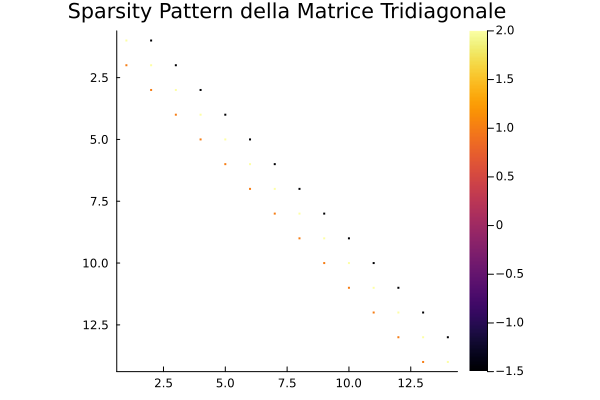

In [17]:
# Definiamo la dimensione della matrice
n = 14

# Creiamo i vettori per le diagonali
main_diag = fill(2.0, n)       # Diagonale principale: tutti 2
lower_diag = fill(1.0, n-1)    # Sottodiagonale: tutti 1
upper_diag = fill(-1.5, n-1)   # Sopradiagonale: tutti -1.5

# Costruiamo la matrice sparsa tridiagonale
# spdiagm accetta coppie (indice diagonale => vettore)
A = spdiagm(0 => main_diag, -1 => lower_diag, 1 => upper_diag)

# Visualizziamo lo sparsity pattern
spy(A, title="Sparsity Pattern della Matrice Tridiagonale", marker=:square)


Il formato sparso è utile non solo per rappresentare matrici sparse, ma anche per eseguire più velocemente operazioni che mantengono la sparsità (cioè il cui output è costituito da matrici sparse, anche se non necessariamente con lo stesso sparsity pattern dell'input).

Consideriamo per esempio la semplice operazione del prodotto di matrici. Se consideriamo una matrice $n\times n$ tridiagonale $A$, il suo quadrato $A^2$ è una matrice pentadiagonale che può essere calcolata in $O(n)$ operazioni invece delle $O(n^3)$ operazioni utilizzate dall'algoritmo standard per il prodotto di matrici.  

Nell'esercizio seguente misureremo il tempo di calcolo del prodotto di matrici.



**Esercizio 2.** Scrivere una `function` che,  per `n in ns`, dove `ns = 100:100:2000`:

* crei la matrice tridiagonale `A`, di dimensioni `n` $\times$ `n`, in formato sparso, avente gli elementi diagonali uguali a $1$,  gli elementi sottodiagonali uguali a 0.5 e gli elementi sopradiagonali uguali a 0.1;
* calcoli il prodotto `A * A`, misuri il tempo impiegato e lo salvi nell'ultima componente di un apposito vettore `time_sparse`,
* converta `A` in formato pieno,
* ripeta il calcolo del prodotto, misuri il tempo impiegato e lo salvi nell'ultima componente di un apposito vettore `time_full`,
* rappresenti i due vettori dei tempi in un unico grafico.

**Suggerimento.** Per misurare il tempo impiegato a eseguire `A * A`, si suggerisce di caricare l'apposito pacchetto `using BenchmarkTools`, poi eseguire l'istruzione `t = @elapsed A * A`. La variabile `t` contiene il tempo impiegato a eseguire l'operazione `A * A`

In [4]:

import Pkg; Pkg.add("BenchmarkTools")
using BenchmarkTools

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


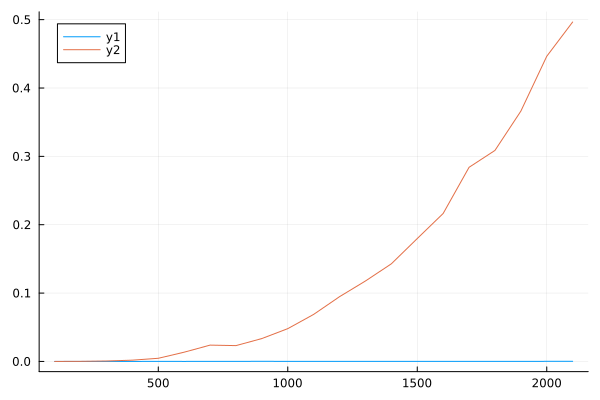

In [12]:
function prodotto()
  timesparse = [0.0]
  timefull = [0.0]
  for n in 100:100:2000
    diag1=fill(1.0,n)
    diag2=fill(0.1,n-1)
    diag3=fill(0.5,n-1)
    A=spdiagm(0 => diag1, 1 => diag2, -1 => diag3)
    t= @elapsed A * A
    push!(timesparse, t)
    A=Array(A)
    t= @elapsed A * A
    push!(timefull, t)
  end
  return timesparse, timefull
end
r=100:100:2100

ts, tf = prodotto()

plot(r, ts)
plot!(r, tf)


---
# 2. The Game of Life

Il Game of Life fu ideato da John Conway (1937-2020) e reso popolare da Martin Gardner negli anni '70.

Il gioco e' ambientato in un universo costituito da una griglia bidimensionale infinita composta da celle quadrate. Ogni cella ha due stati possibili: viva oppure morta. Il gioco comincia con una configurazione data di celle vive e morte ed evolve con tempo discreto. Ad ogni passo del gioco, lo stato di ciascuna cella e' determinato dall'interazione con le otto celle vicine, secondo le regole seguenti:

1. se una cella viva ha esattamente due o tre vicine vive, sopravvive;
1. se una cella morta ha tre vicine vive, prende vita;
1. tutte le celle vive che non soddisfano 1. muoiono;
1. tutte le celle morte che non soddisfano 2. restano morte.

Queste regole possono essere interpretate come condizioni sulla densita' di popolazione che favoriscono o impediscono la sopravvivenza. Un modo alternativo per riassumerle \`e il seguente: al prossimo passo del gioco saranno vive tutte e sole le celle che

(a) sono vive e hanno esattamente due vicine vive, o (b) hanno esattamente tre vicine vive.

Ci proponiamo di scrivere un'implementazione Julia del Game of Life usando le matrici sparse. Come universo prenderemo una matrice sparsa $N\times N$, per un opportuno valore di $N$, in cui le celle morte sono rappresentate da elementi nulli, mentre le celle vive sono rappresentate da elementi uguali a 1. Possiamo usare il comando `scatter` per visualizzare le cellule vive, cioe' gli elementi non nulli di una matrice sparsa. Ad esempio:



```julia
# 1. Create a 10x10 sparse matrix
N = 10
X = spzeros(N, N)

# 2. Assign values
X[6:8, 7] .= 1

# 3. Visualize the sparsity pattern
I, J, V = findnz(X)
scatter(X, markersize = 3, title="Configurazione iniziale", legend=false, xlims = (0, N), ylims = (0, N))


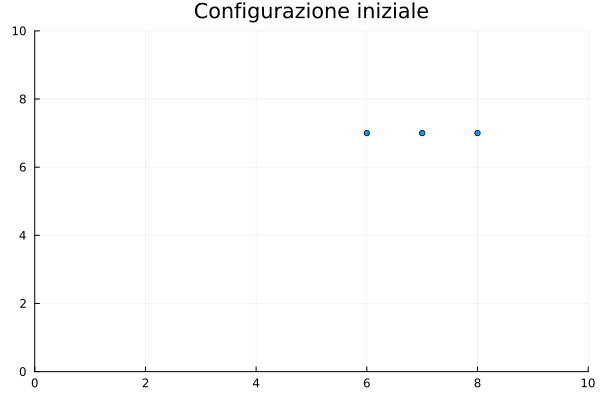

In [ ]:
# 1. Create a 10x10 sparse matrix
N = 10;
X = spzeros(N, N)

# 2. Assign values
X[6:8, 7] .= 1

# 3. Visualize the sparsity pattern
I, J, V = findnz(X)
scatter(I,J, markersize = 3, title="Configurazione iniziale", legend=false, xlims = (0, N), ylims = (0, N))


Applicando le regole del gioco si vede che al prossimo passo saranno vive solo le celle in posizione $(7,6)$, $(7,7)$ e $(7,8)$:

```julia
# 1. Create a 10x10 sparse matrix
N = 10
X = spzeros(N, N)

# 2. Assign values
X[7, 6:8] .= 1

# 3. Visualize the sparsity pattern
I, J, V = findnz(X)
scatter(I,J, markersize = 3, title="Configurazione iniziale", legend=false, xlims = (0, N), ylims = (0, N))


Al passo seguente otterremo una configurazione uguale a quella iniziale. Quindi, con questi dati iniziali, il gioco procede alternando le due configurazioni. Ovviamente, con dati iniziali diversi possono prodursi fenomeni piu' interessanti!


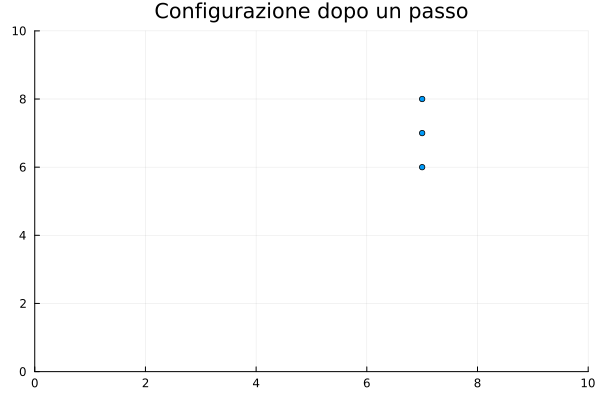

In [ ]:
# 1. Create a 10x10 sparse matrix
N = 10
X = spzeros(N, N)

# 2. Assign values
X[7, 6:8] .= 1

# 3. Visualize the sparsity pattern
I, J, V = findnz(X)
scatter(I,J, markersize = 3, title="Configurazione dopo un passo", legend=false, xlims = (0, N), ylims = (0, N))


**Esercizio 3.** Scrivere una function che implementi Game of Life nel modo seguente:

*  prende in input la configurazione iniziale `X_init` dell'universo  e il numero di passi  `k` da eseguire
*  esegue `k` iterazioni e ad ogni iterazione `step` rappresenta graficamente la configurazione `X`.

   Sperimentate la vostra implementazione con `k`=50 e le due configurazioni iniziali specificate nelle celle seguenti: la configurazione Glider e quella Glider Gun.

**Suggerimento.** Dovremo ``traslare'' la matrice universo `X` nelle 8 direzioni possibili e sommare tutte le matrici traslate, ottenendo cosi' una matrice `Y` che ha come elemento `[i,j]` il numero di vicini vivi della cella di posizione `[i,j]` in `X`. Questa traslazione può essere ottenuta moltiplicando per opportune matrici bidiagonali. In alternativa si possono considerare i vettori di indici `r = [1; 1:N-1]` e
    `s = [2:N; N]` ed estrarre le opportune righe/colonne di `X`. Si osservi per esempio come e' fatta la matrice `X[:,r]`.


**Suggerimento.** Per osservare la configurazione che si evolve nel tempo e' possibile usare il comando `animate` nel ciclo `for` che aggiorna la configurazione `X` nel modo seguente:

```julia
anim = @animate for step in 1:k
        # Calculate matrix X (to be inserted)
    
        # Graphical representation using scatter
        I, J, V = findnz(X)
        f=scatter(I,J,markersize=3,title = "Iteration $step", legend=false, xlims = (0, N), xticks = 0:10:N, ylims = (0, N), yticks = 0:10:N)
end
gif(anim, fps=10)
```

In [ ]:
N=100

function vicine(A, n)
  V=spzeros(n, n)
  d=fill(1, n-1)
  M=spdiagm(1 => d)
  L=transpose(M)
  P=spdiag(-1 => d)
  Q=transpose(P)
  V=A*M + L*A + A*P + Q*A + L*A*M + Q*A*P + Q*A*M + L*A*P
  return V
end


function gameoflife(X_init, k)
  U=X_init
  for i in 1:k
    V=vicine(U, N)
    for i,j in 1:N,1:N
      if U[i,j]==1 && V[i,j]==2




In [19]:
X=A
r=[1; 1:14]
X[:, r]

14×15 SparseMatrixCSC{Float64, Int64} with 42 stored entries:
 2.0  2.0  -1.5    ⋅     ⋅     ⋅   …    ⋅     ⋅     ⋅     ⋅     ⋅     ⋅ 
 1.0  1.0   2.0  -1.5    ⋅     ⋅        ⋅     ⋅     ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅    1.0   2.0  -1.5    ⋅        ⋅     ⋅     ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅    1.0   2.0  -1.5       ⋅     ⋅     ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅    1.0   2.0       ⋅     ⋅     ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅    1.0  …    ⋅     ⋅     ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅     ⋅        ⋅     ⋅     ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅     ⋅      -1.5    ⋅     ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅     ⋅       2.0  -1.5    ⋅     ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅     ⋅       1.0   2.0  -1.5    ⋅     ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅     ⋅   …    ⋅    1.0   2.0  -1.5    ⋅     ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅     ⋅        ⋅     ⋅    1.0   2.0  -1.5    ⋅ 
  ⋅    ⋅     ⋅     ⋅     ⋅     ⋅        ⋅     ⋅     ⋅    1.0  

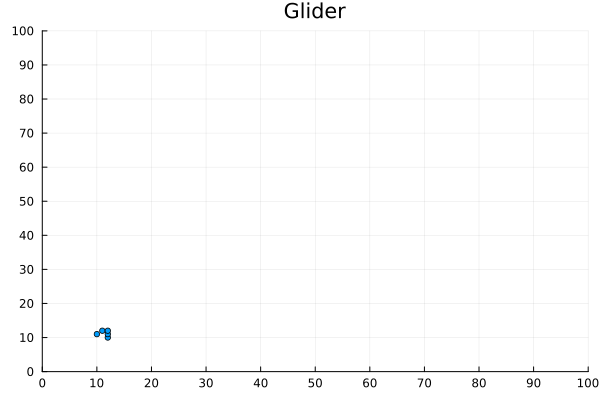

In [ ]:
# Configurazione iniziale Glider
# Initialize
N = 100
X_init = spzeros(N, N)

# Assignments
X_init[12, 10:12] .= 1  # Note the dot for the range assignment
X_init[11, 12] = 1
X_init[10, 11] = 1

# Visualization
 I, J, V = findnz(X_init)
        f=scatter(I,J,markersize=3,title = "Glider", legend=false, xlims = (0, N), xticks = 0:10:N, ylims = (0, N), yticks = 0:10:N)


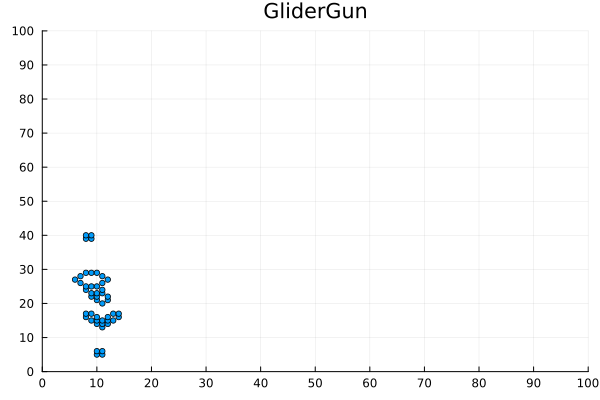

In [ ]:
# Configurazione iniziale GliderGun

# Initialize variables
N = 100
X = spzeros(N, N)

# Matrix Assignments (Note the .= for ranges)
X[8, 16:17] .= 1
X[9, 15] = 1
X[9, 17] = 1
X[10:11, 5:6] .= 1
X[10, 14:16] .= 1
X[11, 13:15] .= 1
X[13, 15] = 1
X[13, 17] = 1
X[12, 14:16] .= 1
X[14, 16:17] .= 1

X[8, 24] = 1
X[9, 22:23] .= 1
X[10, 21:23] .= 1
X[11, 20] = 1
X[11, 23:24] .= 1
X[12, 21:22] .= 1
X[8:10, 25] .= 1
X[8:10, 29] .= 1
X[7, 26] = 1
X[7, 28] = 1
X[6, 27] = 1
X[11, 26] = 1
X[11, 28] = 1
X[12, 27] = 1
X[8:9, 39:40] .= 1

# Visualization
I, J, V = findnz(X)
        f=scatter(I,J,markersize=3,title = "GliderGun", legend=false, xlims = (0, N), xticks = 0:10:N, ylims = (0, N), yticks = 0:10:N)


**Esercizio 3.** Si modifichi l'Esercizio 2 in modo che le nuove configurazioni vengano calcolate considerando le celle dell'ultima riga come adiacenti a quelle della prima riga, e le cellule dell'ultima colonna adiacenti a quelle della prima colonna (se fossimo nel corso di geometria diremmo che l'universo invece di essere un quadrato è un toro).


In [ ]:
# Inserire qui il codice